In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q vit-pytorch torchmetrics matplotlib seaborn --no-cache-dir
!pip install -U torch torchvision --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 266.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 276.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 237.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 225.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 271.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 293.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 279.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 299.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 259.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Import libraries

In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from vit_pytorch import ViT

# Enable Tensor Cores and mixed precision for T4 GPU

In [ ]:
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

# Set random seeds for reproducibility

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

# Device configuration (will use T4 GPU if available)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Using device: cuda (Tesla T4)


# Data path in Google Drive

In [ ]:
data_dir = "/content/drive/MyDrive/Augmented"  # Update with your path
classes = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# Verify dataset structure

In [ ]:
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if not os.path.exists(cls_path):
        raise FileNotFoundError(f"Directory {cls_path} not found")
    print(f"{cls}: {len(os.listdir(cls_path))} images")

glioma: 2437 images
meningioma: 2438 images
pituitary: 2402 images
no_tumor: 1897 images


# WHO Grading System Mapping

In [ ]:
grade_mapping = {
    'glioma': 3,      # Grade IV (Glioblastoma)
    'meningioma': 0,  # Grade I
    'pituitary': 0,   # Grade I
    'no_tumor': -1    # Special case (no tumor)
}

grade_descriptions = [
    "Grade I (Least aggressive, benign)",
    "Grade II (Moderately aggressive)",
    "Grade III (Aggressive)",
    "Grade IV (Most aggressive, malignant)"
]

# Optimized Dataset Class with caching for T4 GPU

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_pretrain=False):
        self.root_dir = root_dir
        self.transform = transform
        self.is_pretrain = is_pretrain
        self.samples = []

        for class_idx, class_name in enumerate(classes):
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                self.samples.append({
                    'path': img_path,
                    'type': class_idx,
                    'grade': grade_mapping[class_name]
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')

            if self.is_pretrain:
                # For pretraining, we return two augmented views
                if self.transform:
                    view1 = self.transform(image)
                    view2 = self.transform(image)
                return view1, view2
            else:
                # For supervised training
                if self.transform:
                    image = self.transform(image)
                return {
                    'image': image,
                    'type': sample['type'],
                    'grade': sample['grade']
                }
        except Exception as e:
            print(f"Error loading {sample['path']}: {e}")
            return self[np.random.randint(0, len(self))]

# Data augmentations for self-supervised learning
pretrain_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.GaussianBlur(kernel_size=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformations for supervised training
finetune_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset for pretraining
pretrain_dataset = BrainTumorDataset(data_dir, transform=pretrain_transform, is_pretrain=True)

# Split dataset (80% train, 20% test)
train_size = int(0.8 * len(pretrain_dataset))
test_size = len(pretrain_dataset) - train_size
pretrain_train_dataset, pretrain_val_dataset = random_split(pretrain_dataset, [train_size, test_size])

# Optimized DataLoader settings for T4 GPU
num_workers = 2 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

pretrain_train_loader = DataLoader(
    pretrain_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

pretrain_val_loader = DataLoader(
    pretrain_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"\nPretraining dataset split:")
print(f"Training samples: {len(pretrain_train_dataset)}")
print(f"Testing samples: {len(pretrain_val_dataset)}")


Pretraining dataset split:
Training samples: 7339
Validation samples: 1835


# Data augmentations for self-supervised learning

In [ ]:
pretrain_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.GaussianBlur(kernel_size=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformations for supervised training
finetune_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset for pretraining
pretrain_dataset = BrainTumorDataset(data_dir, transform=pretrain_transform, is_pretrain=True)

# Split dataset (80% train, 20% test)
train_size = int(0.8 * len(pretrain_dataset))
test_size = len(pretrain_dataset) - train_size
pretrain_train_dataset, pretrain_val_dataset = random_split(pretrain_dataset, [train_size, test_size])

# Optimized DataLoader settings for T4 GPU
num_workers = 2 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

pretrain_train_loader = DataLoader(
    pretrain_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

pretrain_val_loader = DataLoader(
    pretrain_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"\nPretraining dataset split:")
print(f"Training samples: {len(pretrain_train_dataset)}")
print(f"Validation samples: {len(pretrain_val_dataset)}")


Pretraining dataset split:
Training samples: 7339
Validation samples: 1835


# Self-Supervised Model (SimMIM approach)

In [ ]:
class SelfSupervisedViT(nn.Module):
    def __init__(self):
        super().__init__()

        # Create the encoder (ViT)
        self.encoder = ViT(
            image_size=224,
            patch_size=32,
            num_classes=768,
            dim=768,
            depth=4,
            heads=8,
            mlp_dim=1536,
            dropout=0.1,
            emb_dropout=0.1
        )

        # Projection head for contrastive learning
        self.projection_head = nn.Sequential(
            nn.Linear(768, 768),
            nn.GELU(),
            nn.Linear(768, 256)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return projections

# Initialize self-supervised model
ss_model = SelfSupervisedViT().to(device)

# Contrastive loss (NT-Xent loss)
class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        # Concatenate projections
        projections = torch.cat([z_i, z_j], dim=0)

        # Compute similarity matrix
        sim_matrix = torch.matmul(projections, projections.T) / self.temperature

        # Create labels for the contrastive loss
        labels = torch.cat([torch.arange(batch_size) for _ in range(2)], dim=0)
        labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float().to(device)

        # Remove diagonal (self-similarity)
        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(device)
        labels = labels[~mask].view(labels.shape[0], -1)
        sim_matrix = sim_matrix[~mask].view(sim_matrix.shape[0], -1)

        # Select positives and negatives
        positives = sim_matrix[labels.bool()].view(labels.shape[0], -1)
        negatives = sim_matrix[~labels.bool()].view(sim_matrix.shape[0], -1)

        logits = torch.cat([positives, negatives], dim=1)
        labels = torch.zeros(logits.shape[0], dtype=torch.long).to(device)

        loss = self.criterion(logits, labels)
        return loss

# Pretraining setup
ss_optimizer = torch.optim.AdamW(ss_model.parameters(), lr=1e-4, weight_decay=1e-5)
ss_criterion = ContrastiveLoss(temperature=0.1)
scaler = torch.cuda.amp.GradScaler()

# Pretraining function
def pretrain_epoch(epoch):
    ss_model.train()
    running_loss = 0.0
    total = 0

    pbar = tqdm(pretrain_train_loader, desc=f"Pretrain Epoch {epoch+1}")
    for view1, view2 in pbar:
        view1 = view1.to(device, non_blocking=True)
        view2 = view2.to(device, non_blocking=True)

        ss_optimizer.zero_grad(set_to_none=True)

        # Mixed precision training
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            z1 = ss_model(view1)
            z2 = ss_model(view2)
            loss = ss_criterion(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(ss_optimizer)
        scaler.update()

        running_loss += loss.item() * view1.size(0)
        total += view1.size(0)
        pbar.set_postfix({'Loss': running_loss/total, 'LR': ss_optimizer.param_groups[0]['lr']})

    return running_loss / total

<ipython-input-12-65187176>:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Pretraining loop

In [ ]:
num_pretrain_epochs = 10  # Can be increased for better performance
print("\nStarting self-supervised pretraining...")
for epoch in range(num_pretrain_epochs):
    train_loss = pretrain_epoch(epoch)
    print(f"Pretrain Epoch {epoch+1}/{num_pretrain_epochs} Loss: {train_loss:.4f}")

print("\nSelf-supervised pretraining completed!")

# Save pretrained weights
save_dir = "/content/drive/MyDrive/BrainTumorModels"
os.makedirs(save_dir, exist_ok=True)
pretrain_path = os.path.join(save_dir, "pretrained_vit.pth")
torch.save(ss_model.encoder.state_dict(), pretrain_path)
print(f"Saved pretrained encoder to {pretrain_path}")

# Now load the supervised dataset for fine-tuning
finetune_dataset = BrainTumorDataset(data_dir, transform=finetune_transform, is_pretrain=False)

# Split dataset (80% train, 20% test)
train_size = int(0.8 * len(finetune_dataset))
test_size = len(finetune_dataset) - train_size
train_dataset, test_dataset = random_split(finetune_dataset, [train_size, test_size])

# Calculate class weights for imbalanced dataset
# Get the targets from your dataset
targets = [sample['type'] for sample in finetune_dataset.samples]  # Get all targets
train_targets = [finetune_dataset.samples[i]['type'] for i in train_dataset.indices]  # Get train targets only

# Calculate class weights
class_counts = torch.bincount(torch.tensor(train_targets))
num_samples = sum(class_counts)
class_weights = num_samples / (len(class_counts) * (class_counts + 1e-6))  # Add small epsilon to avoid division by zero
weights = class_weights[torch.tensor(train_targets)]

# Create sampler
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders for fine-tuning
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,  # Using weighted sampler instead of shuffle
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

print(f"\nFine-tuning dataset split:")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print(f"Class distribution in training set: {dict(zip(classes, class_counts.tolist()))}")


Starting self-supervised pretraining...


Pretrain Epoch 1: 100%|██████████| 230/230 [18:42<00:00,  4.88s/it, Loss=2.55, LR=0.0001]


Pretrain Epoch 1/10 Loss: 2.5483


Pretrain Epoch 2: 100%|██████████| 230/230 [03:22<00:00,  1.14it/s, Loss=1.26, LR=0.0001]


Pretrain Epoch 2/10 Loss: 1.2648


...

Pretrain Epoch 8/10 Loss: 0.3214


Pretrain Epoch 9: 100%|██████████| 230/230 [03:17<00:00,  1.16it/s, Loss=0.289, LR=0.0001]


Pretrain Epoch 9/10 Loss: 0.2887


Pretrain Epoch 10: 100%|██████████| 230/230 [03:18<00:00,  1.16it/s, Loss=0.28, LR=0.0001]


Pretrain Epoch 10/10 Loss: 0.2798

Self-supervised pretraining completed!
Saved pretrained encoder to /content/drive/MyDrive/BrainTumorModels/pretrained_vit.pth

Fine-tuning dataset split:
Training samples: 7339
Testing samples: 1835
Class distribution in training set: {'glioma': 1934, 'meningioma': 1965, 'pituitary': 1924, 'no_tumor': 1516}


# Hybrid ViT-CNN Model with pretrained ViT

In [ ]:
class HybridTumorModel(nn.Module):
    def __init__(self, num_types=4, num_grades=4):
        super().__init__()

        # CNN Backbone (EfficientNet-B0)
        self.cnn = models.efficientnet_b0(pretrained=True)
        self.cnn_features = nn.Sequential(*list(self.cnn.children())[:-2])

        # Vision Transformer (Initialized with pretrained weights)
        self.vit = ViT(
            image_size=224,
            patch_size=32,
            num_classes=768,
            dim=768,
            depth=4,
            heads=8,
            mlp_dim=1536,
            dropout=0.1,
            emb_dropout=0.1
        )

        # Load pretrained weights
        vit_state_dict = torch.load(pretrain_path)
        self.vit.load_state_dict(vit_state_dict)

        # Feature fusion with proper dimensions
        self.cnn_proj = nn.Linear(1280, 384)
        self.vit_proj = nn.Linear(768, 384)

        # Classifiers
        self.type_classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_types)
        )

        self.grade_classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades)
        )

    def forward(self, x):
        # CNN features
        cnn_feats = self.cnn_features(x)
        cnn_feats = cnn_feats.mean(dim=[2, 3])
        cnn_feats = self.cnn_proj(cnn_feats)

        # ViT features
        vit_feats = self.vit(x)
        vit_feats = self.vit_proj(vit_feats)

        # Feature fusion (element-wise addition)
        fused = cnn_feats + vit_feats

        # Multi-task output
        type_logits = self.type_classifier(fused)
        grade_logits = self.grade_classifier(fused)

        return type_logits, grade_logits

# Initialize model with mixed precision

In [ ]:
model = HybridTumorModel().to(device)
scaler = torch.cuda.amp.GradScaler()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 100MB/s]
<ipython-input-15-1021322196>:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Print model summary

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Loss functions with class weighting
type_weights = torch.tensor([1.0, 1.28, 1.0, 1.01]).to(device)  # Rough inverse frequency weights
type_criterion = nn.CrossEntropyLoss(weight=type_weights)
grade_criterion = nn.CrossEntropyLoss(ignore_index=-1)

# Optimizer (AdamW with weight decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# Training loop with mixed precision for T4 GPU
def train_epoch(epoch):
    model.train()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Fine-tuning Epoch {epoch+1}")
    for batch in pbar:
        images = batch['image'].to(device, non_blocking=True)
        types = batch['type'].to(device, non_blocking=True)
        grades = batch['grade'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision training
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_pred, grade_pred = model(images)
            loss_type = type_criterion(type_pred, types)
            loss_grade = grade_criterion(grade_pred, grades)
            loss = 0.6 * loss_type + 0.4 * loss_grade

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        running_loss += loss.item() * images.size(0)
        _, type_predicted = torch.max(type_pred, 1)
        type_correct += (type_predicted == types).sum().item()

        grade_mask = grades != -1
        if grade_mask.any():
            _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
            grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

        total += images.size(0)
        pbar.set_postfix({
            'Loss': running_loss/total,
            'Type Acc': type_correct/total,
            'LR': optimizer.param_groups[0]['lr']
        })

    epoch_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return epoch_loss, type_acc, grade_acc

def evaluate():
    model.eval()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    all_type_preds = []
    all_type_labels = []
    all_grade_preds = []
    all_grade_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch['image'].to(device, non_blocking=True)
            types = batch['type'].to(device, non_blocking=True)
            grades = batch['grade'].to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                type_pred, grade_pred = model(images)
                loss_type = type_criterion(type_pred, types)
                loss_grade = grade_criterion(grade_pred, grades)
                loss = 0.6 * loss_type + 0.4 * loss_grade

            running_loss += loss.item() * images.size(0)
            _, type_predicted = torch.max(type_pred, 1)
            type_correct += (type_predicted == types).sum().item()

            grade_mask = grades != -1
            if grade_mask.any():
                _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
                grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

            total += images.size(0)

            all_type_preds.extend(type_predicted.cpu().numpy())
            all_type_labels.extend(types.cpu().numpy())
            if grade_mask.any():
                all_grade_preds.extend(grade_predicted.cpu().numpy())
                all_grade_labels.extend(grades[grade_mask].cpu().numpy())

    avg_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return avg_loss, type_acc, grade_acc, all_type_preds, all_type_labels, all_grade_preds, all_grade_labels

# Training parameters
num_epochs = 50  # Reduced epochs for Colab demo
best_acc = 0.0

train_losses = []
val_losses = []
train_type_accs = []
val_type_accs = []
train_grade_accs = []
val_grade_accs = []

# Fine-tuning loop
print("\nStarting fine-tuning...")
for epoch in range(num_epochs):
    train_loss, train_type_acc, train_grade_acc = train_epoch(epoch)
    val_loss, val_type_acc, val_grade_acc, _, _, _, _ = evaluate()
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_type_accs.append(train_type_acc)
    val_type_accs.append(val_type_acc)
    train_grade_accs.append(train_grade_acc)
    val_grade_accs.append(val_grade_acc)

    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Type Acc: {train_type_acc:.2%} | Grade Acc: {train_grade_acc:.2%}")
    print(f"Val Loss: {val_loss:.4f} | Type Acc: {val_type_acc:.2%} | Grade Acc: {val_grade_acc:.2%}")

    # Save best model
    if val_type_acc > best_acc:
        best_acc = val_type_acc
        model_path = os.path.join(save_dir, "best_self_supervised_model_t4.pth")
        torch.save(model.state_dict(), model_path)
        print(f"Saved new best model to {model_path}")

print("\nFine-tuning completed!")


Model architecture:
HybridTumorModel(
  (cnn): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)


Evaluating: 100%|██████████| 58/58 [01:26<00:00,  1.49s/it]



Epoch 1/50 Summary:
Train Loss: 0.4016 | Type Acc: 81.07% | Grade Acc: 54411.11%
Val Loss: 0.1414 | Type Acc: 94.77% | Grade Acc: 15577.78%
Saved new best model to /content/drive/MyDrive/BrainTumorModels/best_self_supervised_model_t4.pth


Evaluating: 100%|██████████| 58/58 [00:15<00:00,  3.79it/s]



Epoch 2/50 Summary:
Train Loss: 0.1406 | Type Acc: 94.69% | Grade Acc: 52730.00%
Val Loss: 0.0871 | Type Acc: 97.00% | Grade Acc: 15655.56%
Saved new best model to /content/drive/MyDrive/BrainTumorModels/best_self_supervised_model_t4.pth


...


Epoch 48/50 Summary:
Train Loss: 0.0014 | Type Acc: 99.96% | Grade Acc: 68437.50%
Val Loss: 0.0225 | Type Acc: 99.62% | Grade Acc: 16088.89%


Evaluating: 100%|██████████| 58/58 [00:15<00:00,  3.87it/s]



Epoch 49/50 Summary:
Train Loss: 0.0014 | Type Acc: 99.97% | Grade Acc: 67325.00%
Val Loss: 0.0222 | Type Acc: 99.51% | Grade Acc: 16077.78%


Evaluating: 100%|██████████| 58/58 [00:14<00:00,  3.96it/s]


Epoch 50/50 Summary:
Train Loss: 0.0029 | Type Acc: 99.82% | Grade Acc: 61677.78%
Val Loss: 0.0249 | Type Acc: 99.67% | Grade Acc: 16100.00%

Fine-tuning completed!


# Load best model

In [ ]:
model.load_state_dict(torch.load(os.path.join(save_dir, "best_self_supervised_model_t4.pth")))
model.eval()

# Final evaluation
test_loss, test_type_acc, test_grade_acc, type_preds, type_labels, grade_preds, grade_labels = evaluate()
print(f"\nFinal Test Performance:")
print(f"Type Accuracy: {test_type_acc:.2%}")
print(f"Grade Accuracy: {test_grade_acc:.2%} (on tumor cases only)")

# Classification reports
print("\nType Classification Report:")
print(classification_report(type_labels, type_preds, target_names=classes))

print("\nGrade Classification Report (tumor cases only):")
if len(grade_labels) > 0:
    unique_grades = np.unique(grade_labels)
    print(classification_report(
        grade_labels,
        grade_preds,
        labels=unique_grades,
        target_names=[grade_descriptions[i] for i in unique_grades]
    ))

Evaluating: 100%|██████████| 58/58 [00:14<00:00,  4.02it/s]


Final Test Performance:
Type Accuracy: 99.62%
Grade Accuracy: 16100.00% (on tumor cases only)

Type Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      1.00      0.99       503
  meningioma       1.00      0.99      0.99       473
   pituitary       1.00      1.00      1.00       478
    no_tumor       1.00      1.00      1.00       381

    accuracy                           1.00      1835
   macro avg       1.00      1.00      1.00      1835
weighted avg       1.00      1.00      1.00      1835


Grade Classification Report (tumor cases only):
                                       precision    recall  f1-score   support

   Grade I (Least aggressive, benign)       1.00      1.00      1.00       951
Grade IV (Most aggressive, malignant)       0.99      1.00      1.00       503

                             accuracy                           1.00      1454
                            macro avg       1.00      1.00      1.00      

# Confusion matrices

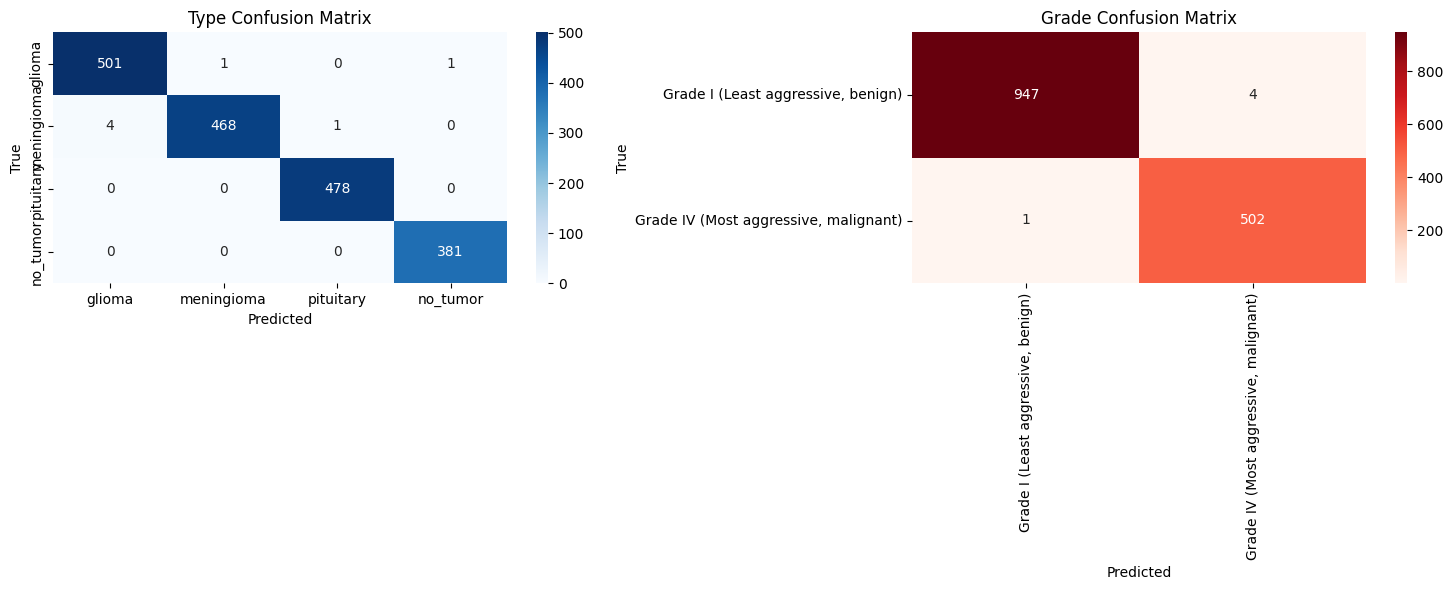

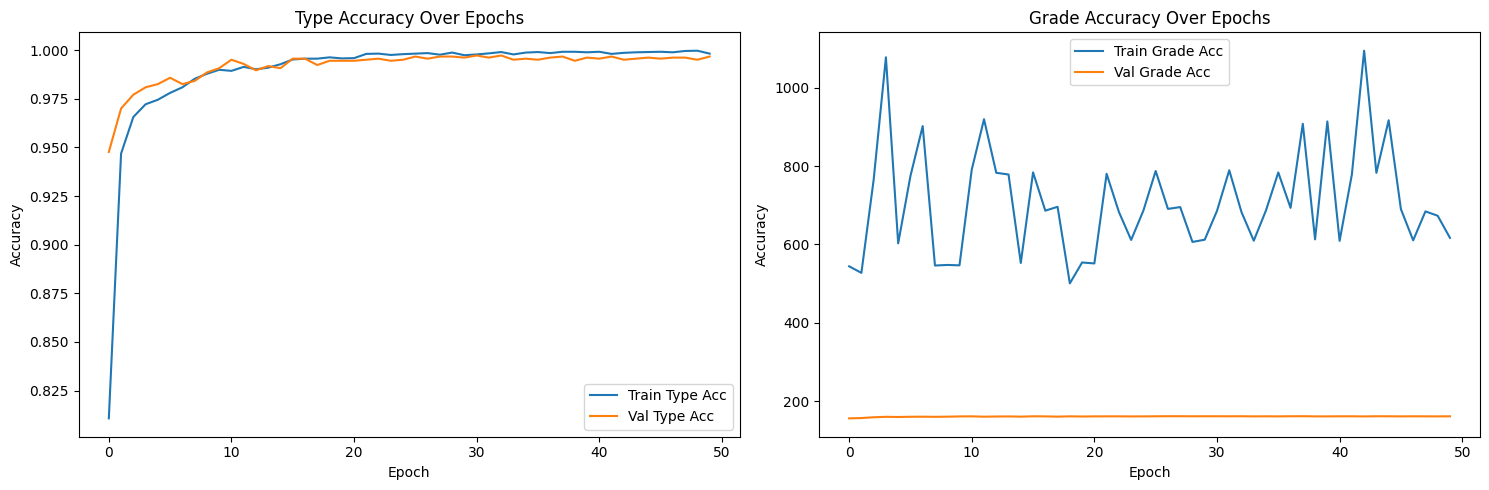

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
cm_type = confusion_matrix(type_labels, type_preds)
sns.heatmap(cm_type, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Type Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

if len(grade_labels) > 0:
    plt.subplot(1, 2, 2)
    cm_grade = confusion_matrix(grade_labels, grade_preds, labels=unique_grades)
    sns.heatmap(cm_grade, annot=True, fmt='d', cmap='Reds',
                xticklabels=[grade_descriptions[i] for i in unique_grades],
                yticklabels=[grade_descriptions[i] for i in unique_grades])
    plt.title('Grade Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_type_accs, label='Train Type Acc')
plt.plot(val_type_accs, label='Val Type Acc')
plt.title('Type Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_grade_accs, label='Train Grade Acc')
plt.plot(val_grade_accs, label='Val Grade Acc')
plt.title('Grade Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Prediction function for custom images

In [ ]:
def predict_tumor(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
    except:
        print(f"Error loading image: {image_path}")
        return None

    with torch.no_grad():
        img_tensor = finetune_transform(img).unsqueeze(0).to(device)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_logits, grade_logits = model(img_tensor)

    type_probs = torch.softmax(type_logits, dim=1)[0]
    grade_probs = torch.softmax(grade_logits, dim=1)[0]

    type_idx = torch.argmax(type_probs).item()
    tumor_type = classes[type_idx]
    type_conf = float(type_probs[type_idx])

    result = {
        'tumor_detected': tumor_type != 'no_tumor',
        'type': tumor_type,
        'type_confidence': type_conf,
        'grade': None,
        'grade_confidence': None,
        'characteristics': []
    }

    if result['tumor_detected']:
        grade_idx = torch.argmax(grade_probs).item()
        result.update({
            'grade': grade_descriptions[grade_idx],
            'grade_confidence': float(grade_probs[grade_idx]),
            'characteristics': [
                "Diffuse growth pattern" if tumor_type == 'glioma' else "Well-circumscribed",
                "High recurrence risk" if grade_idx >= 2 else "Low recurrence risk",
                "Aggressive" if grade_idx >= 2 else "Less aggressive"
            ]
        })

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Input Image\n{os.path.basename(image_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    info_text = f"Type: {tumor_type} ({type_conf:.1%})"
    if result['tumor_detected']:
        info_text += f"\nGrade: {result['grade']}\nCharacteristics:\n- " + "\n- ".join(result['characteristics'])
    plt.text(0.1, 0.5, info_text, fontsize=12, va='center')
    plt.axis('off')
    plt.show()

    return result

# Example prediction

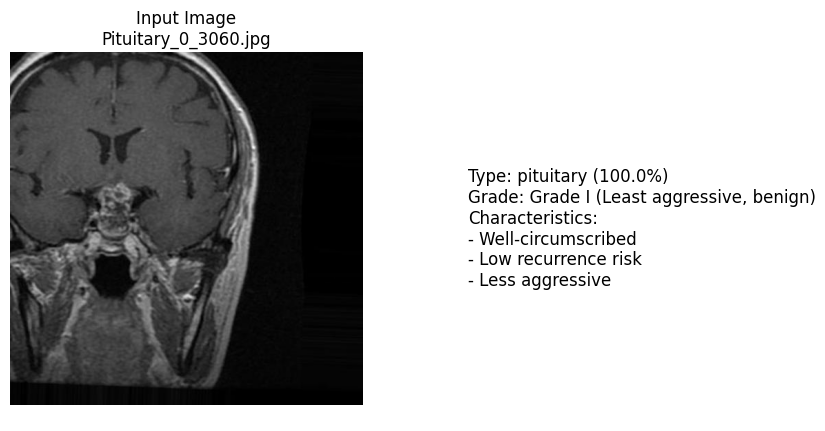


Prediction Result:
      tumor_detected: True
                type: pituitary
     type_confidence: 1.0
               grade: Grade I (Least aggressive, benign)
    grade_confidence: 1.0
     characteristics: ['Well-circumscribed', 'Low recurrence risk', 'Less aggressive']


In [ ]:
sample_image ="/content/drive/MyDrive/Augmented/pituitary/Pituitary_0_3060.jpg"  # Replace with your image
prediction = predict_tumor(sample_image)

if prediction:
    print("\nPrediction Result:")
    for k, v in prediction.items():
        print(f"{k:>20}: {v}")